## 'Mystery of Light' as smoothing & feedback

This is a toy dynamical system on a 1D signal. I start with Gaussian noise so there’s no built-in structure. Then I define an operator that updates each interior point as a convex combination of its current value and the average of its neighbors. The parameter alpha controls how much I preserve the original vs smooth toward local consensus. I apply that operator iteratively, storing each state so I can compare early, mid, and late behavior. Finally I plot the initial noise, a mid iteration, and the final state to see whether the system converges, reveals low-frequency structure, or oversmooths. It’s basically iterative smoothing framed as a generative process.


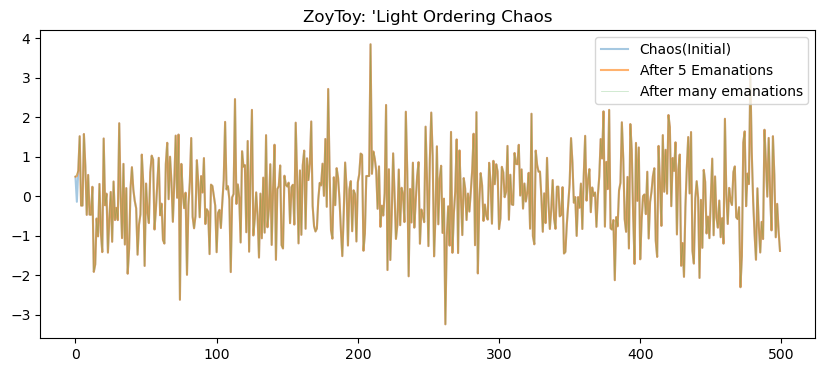

In [10]:
import numpy as np
import matplotlib.pyplot as plt

#setting a random seed makes the results reproducible
np.random.seed(42)

# Initial 'Darkness': pure noise
# creating 500 samples of Gaussian noise with a mean of 0,
# and a standard deviation of 1. Unstructured baseline input
# noise is a god starting point bc any struture that emerges later came from 
# the operator, not the input.

n = 500
x = np.random.normal(0, 1, n)
# This function applies a local smoothing step, bt keeps some of the original
# value; a one steo low pass filter with a feeback parameter
def light_operator(signal, alpha=0.6):
    """Simple structurig operator: local averaging + feedback"""
    y = np.copy(signal) #copy the input so updates are computed from the prev state
                        #not contaminated by in-place changes during the loop
    for i in range(1, len(signal)-1):
        y[i] = alpha * signal[i] + (1-alpha) * 0.5*(signal[i-1] + signal[i+1])
        return y

# Apply successive "emanations"
states = [x]
for _ in range(15):
    states.append(light_operator(states[-1])) #states[-1] = most recent state
    # Iterating the operator 15 times, each time feeding the previous output
    # into the operator-showing how repeated action transforms signal

#Plot Evolution
plt.figure(figsize=(10,4))
plt.plot(states[0], alpha=0.4, label="Chaos(Initial)")
plt.plot(states[5], alpha=0.6, label="After 5 Emanations")
plt.plot(states[-1], linewidth=.5, alpha=0.3, label="After many emanations")
plt.legend()
plt.title("ZoyToy: 'Light Ordering Chaos")
plt.show()
    
    


Even "light" can destroy signal if over-applied